# NumPy Project — Order Analysis, Economic KPIs and Segmentation

> **Project objective:** build a simulated order dataset, calculate economic KPIs, analyze margins and customer satisfaction, identify outliers, and create a business-oriented segmentation.

---

## Notebook structure

1. **Creation of the initial dataset**
2. **Calculation of economic KPIs**
3. **Graphical analysis of margins**
4. **Correlation matrix**
5. **Z-score and outlier detection**
6. **Order segmentation**
7. **Final report**

---

## General logic

The project simulates a business case in which each order is described by quantitative and qualitative variables.  
The objective is not only to calculate technical metrics, but also to transform data into a useful business interpretation: profitability, operational risk, customer satisfaction, and managerial priorities.


# 1. Creation of the initial dataset

This section generates a simulated dataset of **1,000 orders**.  
Each order contains information about quantity, price, cost, delivery days, and customer satisfaction.

The objective is to build a realistic data foundation for economic and operational analysis.


## 1.1 Importing libraries

The following libraries are imported:

- **NumPy**, for data generation, vectorized calculations, and aggregations;
- **Matplotlib**, for chart creation.


In [298]:
import numpy as np
import matplotlib.pyplot as plt

## 1.2 Setting the random seed

The seed makes the random generation **reproducible**.  
This means that, when the notebook is executed again, the same simulated values are obtained.


In [299]:
np.random.seed(42)

## 1.3 Generating quantity and unit price

In this phase, the first variables of the dataset are created:

| Variable | Description |
|---|---|
| `n_ordini` | Total number of simulated orders |
| `quantita` | Quantity purchased for each order |
| `prezzo_unitario` | Unit price generated through a normal distribution |


In [300]:
n_ordini = 1000
quantita = np.random.randint(1,101, size = n_ordini)
prezzo_unitario = np.random.normal(loc=120, scale=35, size=n_ordini)

# loc=120 indica la media;
# scale=35 indica la deviazione standard;
# size=n_ordini indica quanti valori generare.

## 1.4 Cleaning and rounding the price

The unit price is constrained within a realistic range and then rounded to two decimal places.


In [301]:
prezzo_unitario = np.round(np.clip(prezzo_unitario,50,500),2)

## 1.5 Generating costs

The unit cost is calculated as a percentage of the unit price.  
This choice allows the simulation of orders with different levels of profitability.


In [302]:
percentuale_costo = np.random.uniform(0.45,0.85,size=n_ordini)
costo_unitario = np.round(percentuale_costo * prezzo_unitario,2)

## 1.6 Preliminary check on prices and costs

This cell checks the first generated values and verifies that the unit cost is lower than the unit price.


In [303]:
print(prezzo_unitario[:10])
print(costo_unitario[:10])
print(np.all(costo_unitario<prezzo_unitario))

[173.31 138.86  83.7  113.34  89.35  71.6  152.42 186.83  71.05 139.7 ]
[118.2   93.67  56.44  78.36  64.38  55.27  85.04 145.73  46.13  67.17]
True


## 1.7 Generating delivery days

Delivery days are simulated as integer values.  
This variable will later be used to determine customer satisfaction.


In [304]:
giorni_consegna = np.random.randint(1, 16, size = n_ordini)

## 1.8 Building customer satisfaction

Satisfaction starts from a maximum value and is progressively reduced when delivery times increase.

This logic translates a very simple business intuition: slower deliveries tend to reduce satisfaction.


In [305]:
soddisfazione_cliente = np.full(n_ordini,5)
soddisfazione_cliente[giorni_consegna > 5] -=1
soddisfazione_cliente[giorni_consegna > 9] -=1
soddisfazione_cliente[giorni_consegna > 12] -= 1

## 1.9 Adding random noise

A small random component is added to make customer behavior less mechanical and more realistic.


In [306]:
rumore = np.random.randint(-1,2,size=n_ordini)
soddisfazione_cliente = soddisfazione_cliente + rumore
soddisfazione_cliente = np.clip(soddisfazione_cliente,1,5)

In [307]:
print(giorni_consegna[:20])
print(soddisfazione_cliente[:20])
print(np.min(soddisfazione_cliente), np.max(soddisfazione_cliente))

[ 5  8  1 11  7 15 10 10 11  2 15 14  9  1 11 10  6  9  1  4]
[5 3 5 4 5 3 3 3 3 5 2 2 3 4 3 2 3 4 5 5]
1 5


## 1.10 Classifying deliveries

Orders are divided into delivery-time bands:

| Category | Condition |
|---|---|
| Fast delivery | up to 5 days |
| Medium delivery | from 6 to 9 days |
| Slow delivery | from 10 to 12 days |
| Very slow delivery | more than 12 days |


In [308]:
consegna_veloce = giorni_consegna <= 5
consegna_media = (giorni_consegna >5) & (giorni_consegna <= 9)
consegna_lenta = (giorni_consegna >9) & (giorni_consegna <= 12)
consegna_molto_lenta = giorni_consegna > 12

In [309]:
media_veloce = np.round(np.mean(soddisfazione_cliente[consegna_veloce]),2)
media_media = np.round(np.mean(soddisfazione_cliente[consegna_media]),2)
media_lenta = np.round(np.mean(soddisfazione_cliente[consegna_lenta]),2)
media_molto_lenta = np.round(np.mean(soddisfazione_cliente[consegna_molto_lenta]),2)

In [310]:
print(f"la consegna veloce ha una media di: {media_veloce}")
print(f"la consegna media ha una media di {media_media}")
print(f"la consegna lenta ha una media di {media_lenta}")
print(f"la consegna molto lenta ha una media di {media_molto_lenta}")

la consegna veloce ha una media di: 4.69
la consegna media ha una media di 4.02
la consegna lenta ha una media di 3.02
la consegna molto lenta ha una media di 2.04


## 1.11 Creating the order matrix

The individual variables are combined into a single NumPy matrix called `ordini`.

Each row represents one order, while each column represents one variable.


In [311]:
ordini = np.column_stack((quantita,
                          prezzo_unitario,
                          costo_unitario,
                          giorni_consegna,
                          soddisfazione_cliente
                          ))

In [312]:
print(ordini.shape)
print(ordini[:5])
print(ordini.dtype)

(1000, 5)
[[ 52.   173.31 118.2    5.     5.  ]
 [ 93.   138.86  93.67   8.     3.  ]
 [ 15.    83.7   56.44   1.     5.  ]
 [ 72.   113.34  78.36  11.     4.  ]
 [ 61.    89.35  64.38   7.     5.  ]]
float64


# 2. Economic KPIs

In this section, the main economic indicators of the dataset are calculated:

| KPI | Meaning |
|---|---|
| **Revenue** | Economic value generated by each order |
| **Cost** | Total cost associated with the order |
| **Margin** | Difference between revenue and cost |
| **Margin percentage** | Percentage profitability of the order |

These indicators make it possible to evaluate both the overall economic performance and the performance of individual orders.


## 2.1 Calculating KPIs for each order

Here, revenue, cost, margin, and margin percentage are calculated for each order in the dataset.


In [313]:
ricavo = quantita * prezzo_unitario
costo =  quantita * costo_unitario
margine =  ricavo - costo
margine_percentuale = margine / ricavo * 100

## 2.2 Aggregated economic KPIs

The KPIs are aggregated at the overall level to obtain an economic snapshot of the dataset.


In [314]:
ricavo_totale = np.round(np.sum(ricavo),2)
costo_totale =  np.round(np.sum(costo),2)
margine_totale = np.round(np.sum(margine),2)
margine_percentuale_totale = np.round((margine_totale / ricavo_totale) * 100,2)
margine_percentuale_medio = np.round(np.mean(margine_percentuale),2)

In [315]:
print(f"il ricavo totale è di: {ricavo_totale}")
print(f"il costo totale è di: {costo_totale}")
print(f"il margine totale è di: {margine_totale}")
print(f"il margine percentuale totale è di: {margine_percentuale_totale}%")
print(f"il margine percentuale medio è di: {margine_percentuale_medio}%")

il ricavo totale è di: 6137214.51
il costo totale è di: 3974918.67
il margine totale è di: 2162295.84
il margine percentuale totale è di: 35.23%
il margine percentuale medio è di: 35.09%


## 2.3 Descriptive statistics of the margin

These metrics describe the margin distribution:

- mean;
- median;
- minimum;
- maximum;
- standard deviation.


In [316]:
margine_medio = np.round(np.mean(margine),2)
margine_mediano = np.round(np.median(margine),2)
margine_minimo = np.round(np.min(margine),2)
margine_massimo =np.round(np.max(margine),2)
deviazione_standard_margine = np.round(np.std(margine),2)

In [317]:
print(f"il margine medio è di: {margine_medio}")
print(f"il margine mediano è di: {margine_mediano}")
print(f"il margine minimo è di: {margine_minimo}")
print(f"il margine massimo è di: {margine_massimo}")
print(f"la deviazione standard del margine è di: {deviazione_standard_margine}")

il margine medio è di: 2162.3
il margine mediano è di: 1785.15
il margine minimo è di: 14.83
il margine massimo è di: 10622.47
la deviazione standard del margine è di: 1697.22


## 2.4 Identifying the best and worst orders

`np.argmax()` and `np.argmin()` are used to identify the orders with the highest and lowest total margin.


In [318]:
indice_migliore_margine = np.argmax(margine) #posizione nel dataset
indice_peggiore_margine = np.argmin(margine) #posizione nel dataset
ordine_migliore_margine = np.round(ordini[indice_migliore_margine],2) #stampo ordine da indice
ordine_peggiore_margine = np.round(ordini[indice_peggiore_margine],2) #stampo ordine da indice

In [319]:
print(f"l'ordine migliore per margine è: {ordine_migliore_margine}, con il numero {indice_migliore_margine}")
print(f"il margine dell'ordine migliore è: {np.round(margine[indice_migliore_margine], 2)}") #stampo margine da indice

print(f"l'ordine peggiore per margine è: {ordine_peggiore_margine}, con il numero {indice_peggiore_margine}")
print(f"il margine dell'ordine peggiore è: {np.round(margine[indice_peggiore_margine], 2)}") #stampo margine da indice

l'ordine migliore per margine è: [ 97.   205.94  96.43   5.     5.  ], con il numero 353
il margine dell'ordine migliore è: 10622.47
l'ordine peggiore per margine è: [ 1.   96.62 81.79 14.    3.  ], con il numero 806
il margine dell'ordine peggiore è: 14.83


## 2.5 Unit margin analysis

The unit margin makes it possible to distinguish profitability per item from the total profitability of the order.

An order can have a high unit margin but not the highest total margin if the quantity sold is low.


In [320]:
margine_unitario = np.round(prezzo_unitario - costo_unitario,2) #calcolo margine unitario
indice_margine_unitario_migliore = np.argmax(margine_unitario) #calcolo indice margine unitario migliore
indice_margine_unitario_peggiore = np.argmin(margine_unitario) #calcolo indice margine unitario peggiore
ordine_margine_unitario_migliore = np.round(ordini[indice_margine_unitario_migliore],2) #stampa ordine margine unitario migliore da indice
ordine_margine_unitario_peggiore = np.round(ordini[indice_margine_unitario_peggiore],2) #stampa ordine margine unitario migliore da indice

In [321]:
print(f"l'ordine migliore per margine unitario è: {ordine_margine_unitario_migliore}, con il numero {indice_margine_unitario_migliore}")
print(f"il margine unitario migliore è: {np.round(margine_unitario[indice_margine_unitario_migliore], 2)}")
print(f"il margine totale dell'ordine con miglior margine unitario è: {np.round(margine[indice_margine_unitario_migliore], 2)}")

print(f"l'ordine peggiore per margine unitario è: {ordine_margine_unitario_peggiore}, con il numero {indice_margine_unitario_peggiore}")
print(f"il margine unitario peggiore è: {np.round(margine_unitario[indice_margine_unitario_peggiore], 2)}")
print(f"il margine totale dell'ordine con peggior margine unitario è: {np.round(margine[indice_margine_unitario_peggiore], 2)}")

l'ordine migliore per margine unitario è: [ 97.   205.94  96.43   5.     5.  ], con il numero 353
il margine unitario migliore è: 109.51
il margine totale dell'ordine con miglior margine unitario è: 10622.47
l'ordine peggiore per margine unitario è: [17.   50.   42.12  6.    5.  ], con il numero 852
il margine unitario peggiore è: 7.88
il margine totale dell'ordine con peggior margine unitario è: 133.96


## 2.6 Consistency checks

These checks verify that the identified indices actually correspond to the maximum and minimum margin values.


In [322]:
controllo_margine_massimo = np.round(margine[indice_migliore_margine],2) == margine_massimo
controllo_margine_minimo = np.round(margine[indice_peggiore_margine],2) == margine_minimo

In [323]:
print(controllo_margine_massimo)
print(controllo_margine_minimo)

True
True


# 3. Graphical analysis of margins

In this part, charts are used to observe the distribution of margins and the relationship between quantity sold and profitability.

Graphical analysis is useful because it allows you to quickly identify:
- concentration of orders within specific margin ranges;
- presence of extreme values;
- possible relationships between variables.


## 3.1 Margin histogram

The histogram shows how order margins are distributed.  
The vertical lines indicate the mean and the median.


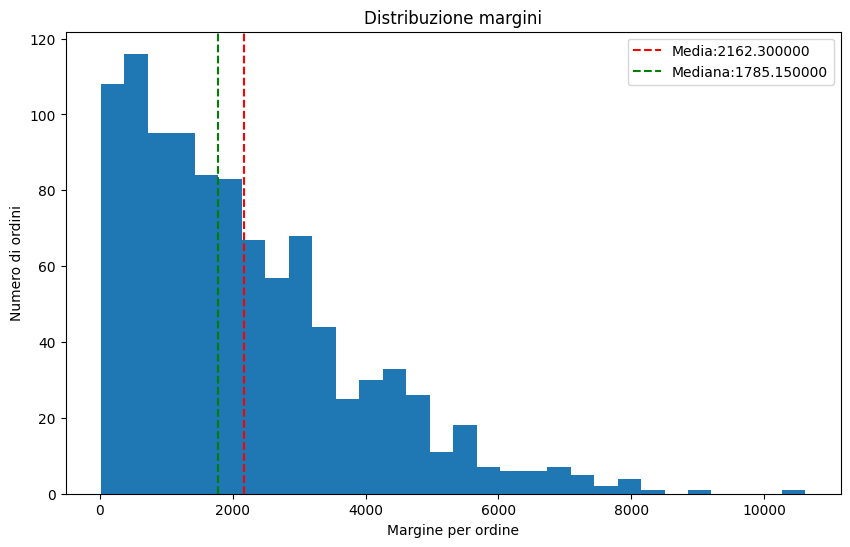

In [324]:
plt.figure(figsize=(10,6))

plt.hist(margine, bins=30)

plt.axvline(margine_medio, color ="Red",linestyle="--", label=f"Media:{margine_medio:2f}")
plt.axvline(margine_mediano, color ="Green",linestyle="--", label=f"Mediana:{margine_mediano:2f}")

plt.title("Distribuzione margini")
plt.xlabel("Margine per ordine")
plt.ylabel("Numero di ordini")
plt.legend()
plt.show()


### Interpretation of the margin histogram

The margin distribution does not appear perfectly symmetrical.  
It is right-skewed: most orders are concentrated around medium-low margins, while a few orders with very high margins extend the right tail of the distribution.

This behavior is consistent with the fact that the **mean is higher than the median**: some particularly high values shift the mean to the right.


## 3.2 Relationship between quantity and margin

The scatter plot makes it possible to visually observe whether orders with higher quantities tend to generate higher margins.


Text(0, 0.5, 'Margine')

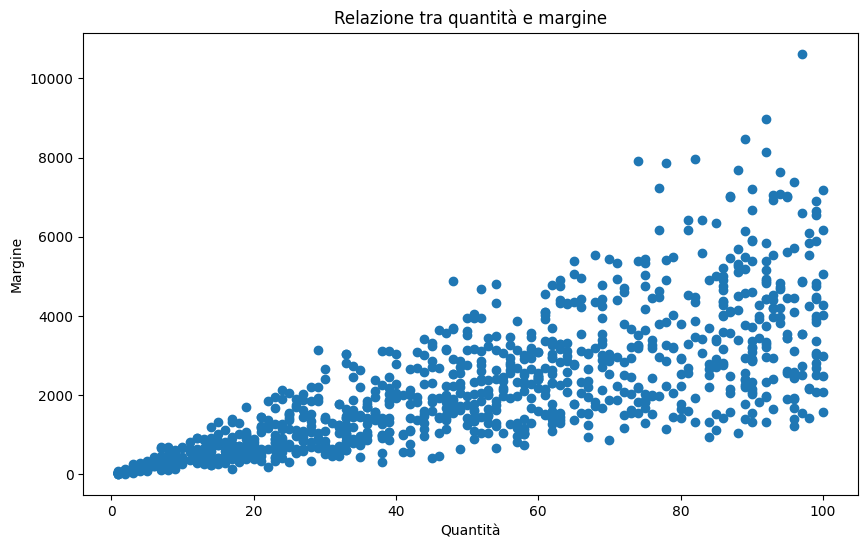

In [325]:
plt.figure(figsize=(10,6))

plt.scatter(quantita,margine)

plt.title("Relazione tra quantità e margine")
plt.xlabel("Quantità")
plt.ylabel("Margine")

## 3.3 Correlation between quantity and margin

Correlation provides a synthetic measure of the strength of the linear relationship between quantity and margin.


In [326]:
correlazione_quantita_margine = np.round(np.corrcoef(quantita,margine)[0,1],2)
print(correlazione_quantita_margine)

0.75


### Interpretation of the quantity–margin scatter plot

A positive correlation can be observed between **quantity** and **margin**: as the ordered quantity increases, the margin also tends to increase.

However, it is important to consider that margin does not depend only on quantity.  
Unit price, unit cost, and unit margin also contribute to the final profitability of the order.


# 4. Correlation matrix

The correlation matrix allows the analysis of the linear relationship between the numerical variables in the dataset.

The correlation value ranges between:

| Value | Interpretation |
|---:|---|
| **+1** | Perfect positive correlation |
| **0** | No linear relationship |
| **-1** | Perfect negative correlation |

This analysis helps understand which variables move together and which ones may have a stronger influence on margin.


## 4.1 Preparing variables for correlation

The numerical variables are combined into a dedicated matrix for correlation analysis.


In [327]:
variabili_corr = np.column_stack((quantita,
                                  prezzo_unitario,
                                  costo_unitario,
                                  giorni_consegna,
                                  soddisfazione_cliente,
                                  margine,
                                  margine_percentuale,
                                  margine_unitario
                                  ))

## 4.2 Calculating the correlation matrix

`np.corrcoef()` calculates the correlation between all selected variables.


In [328]:
matrice_corr = np.corrcoef(variabili_corr, rowvar=False)
matrice_corr = np.round(matrice_corr,2)
print(matrice_corr)

[[ 1.    0.   -0.01  0.02 -0.03  0.75  0.01  0.02]
 [ 0.    1.    0.83 -0.02  0.01  0.36 -0.    0.63]
 [-0.01  0.83  1.   -0.04  0.01  0.04 -0.53  0.09]
 [ 0.02 -0.02 -0.04  1.   -0.77  0.02  0.04  0.02]
 [-0.03  0.01  0.01 -0.77  1.   -0.02 -0.01  0.  ]
 [ 0.75  0.36  0.04  0.02 -0.02  1.    0.44  0.58]
 [ 0.01 -0.   -0.53  0.04 -0.01  0.44  1.    0.75]
 [ 0.02  0.63  0.09  0.02  0.    0.58  0.75  1.  ]]


## 4.3 Matrix labels

The labels make the heatmap more readable by associating each row and column with the correct variable.


In [329]:
etichette = [
    "quantita",
    "prezzo_unitario",
    "costo_unitario",
    "giorni_consegna",
    "soddisfazione",
    "margine",
    "margine_percentuale",
    "margine_unitario"
    ]

In [330]:
print(etichette)
print(matrice_corr)

['quantita', 'prezzo_unitario', 'costo_unitario', 'giorni_consegna', 'soddisfazione', 'margine', 'margine_percentuale', 'margine_unitario']
[[ 1.    0.   -0.01  0.02 -0.03  0.75  0.01  0.02]
 [ 0.    1.    0.83 -0.02  0.01  0.36 -0.    0.63]
 [-0.01  0.83  1.   -0.04  0.01  0.04 -0.53  0.09]
 [ 0.02 -0.02 -0.04  1.   -0.77  0.02  0.04  0.02]
 [-0.03  0.01  0.01 -0.77  1.   -0.02 -0.01  0.  ]
 [ 0.75  0.36  0.04  0.02 -0.02  1.    0.44  0.58]
 [ 0.01 -0.   -0.53  0.04 -0.01  0.44  1.    0.75]
 [ 0.02  0.63  0.09  0.02  0.    0.58  0.75  1.  ]]


## 4.4 Correlation heatmap

The heatmap translates the numerical matrix into a visual representation.  
The values inside the cells make it easier to immediately read the strength and direction of the relationships.


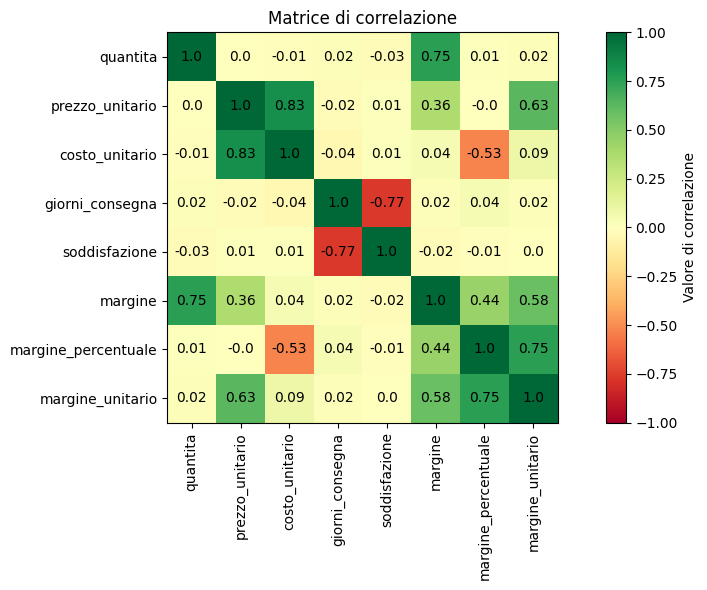

In [331]:
# Creo una nuova figura e imposto la dimensione del grafico
plt.figure(figsize=(10, 6))

# Creo la heatmap della matrice di correlazione
# cmap="RdYlGn" usa una scala colori rosso-giallo-verde:
# - rosso per correlazioni negative
# - giallo per valori vicini a zero
# - verde per correlazioni positive
# vmin=-1 e vmax=1 fissano la scala della correlazione tra -1 e +1
plt.imshow(matrice_corr, cmap="RdYlGn", vmin=-1, vmax=1)

# Aggiungo la barra laterale dei colori per interpretare i valori
plt.colorbar(label="Valore di correlazione")

# Imposto le etichette sull'asse X
# np.arange(len(etichette)) crea le posizioni numeriche delle variabili
# rotation=90 ruota le etichette per renderle più leggibili
plt.xticks(np.arange(len(etichette)), etichette, rotation=90)

# Imposto le etichette sull'asse Y
plt.yticks(np.arange(len(etichette)), etichette)

# Inserisco il valore numerico della correlazione dentro ogni cella
for i in range(len(etichette)):
    for j in range(len(etichette)):
        plt.text(
            j,                      # posizione sull'asse X
            i,                      # posizione sull'asse Y
            round(matrice_corr[i, j], 2),  # valore della correlazione arrotondato a 2 decimali
            ha="center",            # allineamento orizzontale al centro
            va="center",            # allineamento verticale al centro
            color="black"           # colore del testo
        )

# Aggiungo il titolo del grafico
plt.title("Matrice di correlazione")

# Miglioro leggermente la disposizione degli elementi del grafico
plt.tight_layout()

# Mostro il grafico finale
plt.show()

# 5. Margin Z-score

The **Z-score** measures how far a value is from the mean in terms of standard deviations.

Conceptual formula:

$$
Z = \frac{x - \mu}{\sigma}
$$

Where:

| Symbol | Meaning |
|---|---|
| $x$ | observed value |
| $\mu$ | mean |
| $\sigma$ | standard deviation |

In this project, it is applied to the **margin** to identify economically anomalous or particularly relevant orders.


## 5.1 Calculating the Z-score

The Z-score is calculated for all margins in order to standardize the distribution and compare orders against the mean.


In [332]:
zscore_margine = (margine - np.mean(margine)) / np.std(margine)
primi_zscore_margine = np.round(zscore_margine[:10],2)
zscore_margine_minimo = np.round(np.min(zscore_margine),2)
zscore_margine_massimo = np.round(np.max(zscore_margine),2)
zscore_margine_medio = np.round(np.mean(zscore_margine),2)
zscore_margine_deviazione_standard = np.round(np.std(zscore_margine),2)

In [333]:
print(f"i primi 10 z-score sono: {primi_zscore_margine}")
print(f"il z-score minimo è: {zscore_margine_minimo}")
print(f"il z-score massimo è: {zscore_margine_massimo}")
print(f"il z-score medio è: {zscore_margine_medio}")
print(f"la deviazione standard è: {zscore_margine_deviazione_standard}")

i primi 10 z-score sono: [ 0.41  1.2  -1.03  0.21 -0.38 -1.07  2.02  0.83 -0.17  1.93]
il z-score minimo è: -1.27
il z-score massimo è: 4.98
il z-score medio è: 0.0
la deviazione standard è: 1.0


## 5.2 Creating filters for outliers

Boolean filters are created to identify orders with margins that are much higher or much lower than the mean.


In [334]:
indice_outlier_alti_2 = zscore_margine > 2
indice_outlier_alti_3 = zscore_margine > 3
indice_outlier_basso_2 = zscore_margine < -2
indice_outlier_basso_3 = zscore_margine < -3

## 5.3 Counting outliers

This part counts how many orders exceed the defined thresholds.


In [335]:
outlier_alti_2 = np.sum(indice_outlier_alti_2)
outlier_alti_3 = np.sum(indice_outlier_alti_3)
outlier_basso_2 = np.sum(indice_outlier_basso_2)
outlier_basso_3 = np.sum(indice_outlier_basso_3)

In [336]:
print(f"il numero di ordini con z-score superiore a 2 è: {outlier_alti_2}")
print(f"il numero di ordini con z-score superiore a 3 è: {outlier_alti_3}")
print(f"il numero di ordini con z-score inferiore a -2 è: {outlier_basso_2}")
print(f"il numero di ordini con z-score inferiore a -3 è: {outlier_basso_3}")

il numero di ordini con z-score superiore a 2 è: 42
il numero di ordini con z-score superiore a 3 è: 10
il numero di ordini con z-score inferiore a -2 è: 0
il numero di ordini con z-score inferiore a -3 è: 0


## 5.4 Displaying the first outlier orders

The first orders belonging to the high-outlier categories are printed.


In [337]:
print("primi 5 ordini outlier alti >2:")
print(ordini[indice_outlier_alti_2][:5])
print("primi 5 ordini outlier alti >3:")
print(ordini[indice_outlier_alti_3][:5])

primi 5 ordini outlier alti >2:
[[ 83.   152.42  85.04  10.     3.  ]
 [ 78.   192.64  92.    12.     3.  ]
 [ 81.   150.49  71.15  15.     3.  ]
 [ 90.   149.03  69.07   3.     4.  ]
 [100.   160.03  98.33  14.     2.  ]]
primi 5 ordini outlier alti >3:
[[ 78.   192.64  92.    12.     3.  ]
 [ 82.   181.98  84.95  10.     4.  ]
 [ 97.   205.94  96.43   5.     5.  ]
 [ 96.   159.11  82.22   7.     3.  ]
 [ 92.   178.54  81.05   5.     5.  ]]


# 6. Graphical representation of the Z-score

The following charts help visualize the distribution of Z-scores and identify orders that exceed specific thresholds.

The main thresholds are:

| Threshold | Interpretation |
|---:|---|
| **Z > 2** | Orders with a margin much higher than the mean |
| **Z > 3** | Extremely profitable orders |
| **Z < -2** | Orders with a margin much lower than the mean |
| **Z < -3** | Extremely critical orders from an economic perspective |


## 6.1 Z-score histogram

The histogram shows the standardized distribution of margins.  
The vertical lines help interpret anomaly thresholds.


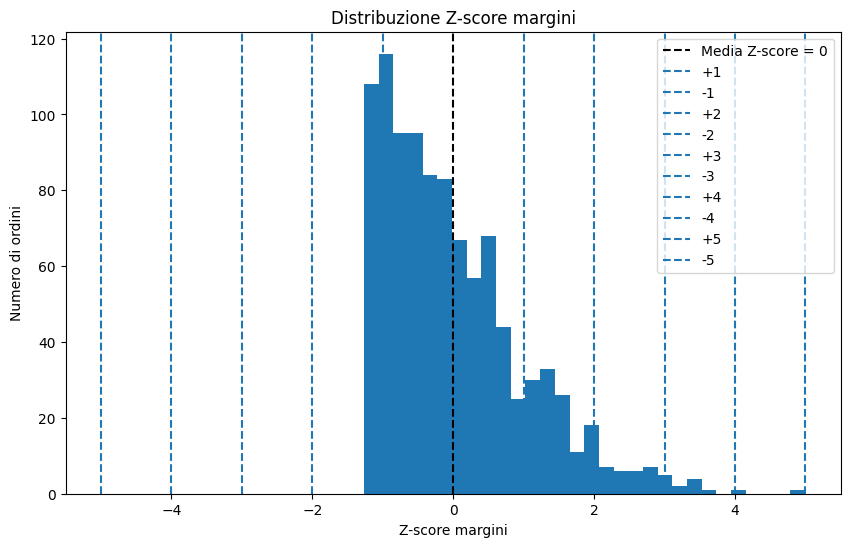

In [338]:
from matplotlib import lines
plt.figure(figsize=(10,6))

plt.hist(zscore_margine, bins=30)

plt.axvline(0, linestyle="--", color="Black", label="Media Z-score = 0")
plt.axvline(1, linestyle="--", label="+1")
plt.axvline(-1, linestyle="--", label="-1")
plt.axvline(2, linestyle="--", label="+2")
plt.axvline(-2, linestyle="--", label="-2")
plt.axvline(3, linestyle="--", label="+3")
plt.axvline(-3,linestyle="--", label="-3")
plt.axvline(4,linestyle="--", label="+4")
plt.axvline(-4,linestyle="--", label="-4")
plt.axvline(5,linestyle="--", label="+5")
plt.axvline(-5,linestyle="--", label="-5")

plt.title("Distribuzione Z-score margini")
plt.xlabel("Z-score margini")
plt.ylabel("Numero di ordini")
plt.legend()
plt.show()



## 6.2 Z-score by order index

This chart makes it possible to visually identify which orders exceed the attention thresholds.


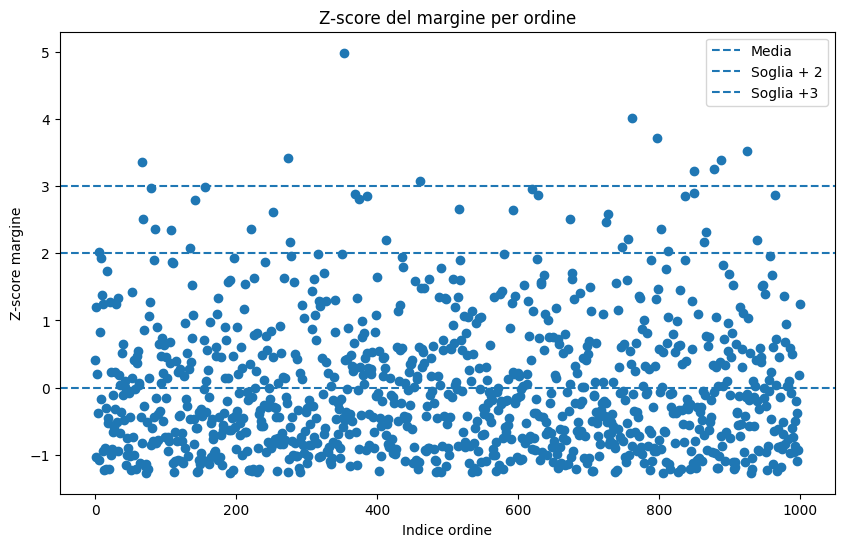

In [339]:
plt.figure(figsize=(10,6))

plt.scatter(np.arange(n_ordini),zscore_margine)

plt.axhline(0, linestyle="--",label="Media")
plt.axhline(2, linestyle="--",label="Soglia + 2")
plt.axhline(3, linestyle="--",label="Soglia +3")

plt.title("Z-score del margine per ordine")
plt.xlabel("Indice ordine")
plt.ylabel("Z-score margine")
plt.legend()
plt.show()

## 6.3 Extracting the strongest outliers

Orders with a Z-score greater than 3 are selected, meaning those with an extremely higher margin than the average.


In [340]:
indice_outlier_3 = np.where(indice_outlier_alti_3)[0]
print(indice_outlier_3)

[ 67 273 353 461 762 797 850 877 888 924]


In [341]:
ordini_outlier_alti_3 = ordini[indice_outlier_3]
margini_outlier_alti_3 = margine[indice_outlier_3]
zscore_outlier_alti_3 = zscore_margine[indice_outlier_3]

## 6.4 Creating the outlier table

Outlier information is collected into a single table, useful for subsequent analysis.


In [342]:
tabella_outlier_alti_3 = np.column_stack((indice_outlier_3,
                           ordini_outlier_alti_3,
                           margini_outlier_alti_3,
                           zscore_outlier_alti_3
                           ))

In [343]:
tabella_outlier_alti_3 = np.round(tabella_outlier_alti_3,2)

## 6.5 Sorting outliers

Outliers are sorted in descending order by margin, so that the most economically relevant orders are immediately highlighted.


In [344]:
np.set_printoptions(suppress=True, precision=2)

tabella_outlier_ordinata = tabella_outlier_alti_3[
    np.argsort(tabella_outlier_alti_3[:, 7])[::-1]
]

print(tabella_outlier_ordinata)
#[indice, quantità, prezzo_unitario, costo_unitario, giorni_consegna, soddisfazione, margine, z_score]

[[  353.      97.     205.94    96.43     5.       5.   10622.47     4.98]
 [  762.      92.     178.54    81.05     5.       5.    8969.08     4.01]
 [  797.      89.     207.25   112.18    14.       1.    8461.23     3.71]
 [  924.      92.     173.5     85.14     4.       5.    8129.12     3.52]
 [  273.      82.     181.98    84.95    10.       4.    7956.46     3.41]
 [  888.      74.     195.51    88.69    13.       1.    7904.68     3.38]
 [   67.      78.     192.64    92.      12.       3.    7849.92     3.35]
 [  877.      88.     179.91    92.59    13.       3.    7684.16     3.25]
 [  850.      94.     153.23    72.02    14.       1.    7633.74     3.22]
 [  461.      96.     159.11    82.22     7.       3.    7381.44     3.08]]


# 7. Business segmentation of orders

In this section, orders are classified into operational segments.

The logic combines:

- **profitability**, measured through the Z-score;
- **customer satisfaction**, useful for evaluating relationship risk;
- **delivery times**, used in the subsequent KPIs.

This is the part that is closest to a managerial interpretation of the dataset.


## 7.1 Defining the segments

| Segment | Logic |
|---|---|
| **Highly profitable but risky** | Extremely high margin but low satisfaction |
| **Profitable but risky** | High margin but low satisfaction |
| **Top performer** | High margin and high satisfaction |
| **Critical** | Low margin and low satisfaction |
| **Standard** | Orders that do not fall into the previous segments |


In [345]:
filtro_profittevoli_rischiosi = ((zscore_margine > 2) & (zscore_margine < 3)) & (soddisfazione_cliente <= 2)
filtro_molto_profittevoli_rischiosi = (zscore_margine > 3) & (soddisfazione_cliente <= 2)
filtro_top_performer = (zscore_margine > 2) & (soddisfazione_cliente >= 4)
filtro_critici = (zscore_margine < -1) & (soddisfazione_cliente <= 2)
filtro_standard = ~(filtro_top_performer | filtro_profittevoli_rischiosi | filtro_critici | filtro_molto_profittevoli_rischiosi)

## 7.2 Counting orders by segment

The number of orders belonging to each segment is calculated.


In [346]:
numero_ordini_molto_profittevoli_rischiosi = np.sum(filtro_molto_profittevoli_rischiosi)
numero_ordini_profittevoli_rischiosi = np.sum(filtro_profittevoli_rischiosi)
numero_ordini_top_performer = np.sum(filtro_top_performer)
numero_ordini_critici = np.sum(filtro_critici)
numero_ordini_standard = np.sum(filtro_standard)

print(f"il numero degli ordini molto profittevoli ma rischiosi, con zscore >3 e con soddisfazione <= 2 è pari a {numero_ordini_molto_profittevoli_rischiosi}")
print(f"il numero degli ordini profittevoli ma rischiosi, con zscore tra 2 e 3 e con soddisfazione <= 2 è pari a {numero_ordini_profittevoli_rischiosi}")
print(f"il numero degli ordini top performer, con zscore > 2 e con soddisfazione >= 4 è pari a {numero_ordini_top_performer}")
print(f"il numero degli ordini critichi, con zscore <-1 e con soddisfazione <=2 è pari a {numero_ordini_critici}")
print(f"il numero degli ordini che non rientra nelle precedenti classificazioni è pari a {numero_ordini_standard}")

il numero degli ordini molto profittevoli ma rischiosi, con zscore >3 e con soddisfazione <= 2 è pari a 3
il numero degli ordini profittevoli ma rischiosi, con zscore tra 2 e 3 e con soddisfazione <= 2 è pari a 6
il numero degli ordini top performer, con zscore > 2 e con soddisfazione >= 4 è pari a 24
il numero degli ordini critichi, con zscore <-1 e con soddisfazione <=2 è pari a 24
il numero degli ordini che non rientra nelle precedenti classificazioni è pari a 943


## 7.3 Segmentation check

This check verifies that all orders have been assigned to one and only one segment.


In [347]:
totale_segmenti = (numero_ordini_molto_profittevoli_rischiosi + numero_ordini_profittevoli_rischiosi + numero_ordini_top_performer + numero_ordini_critici + numero_ordini_standard)
print(f"il totale dei segmenti analizzati sono: {totale_segmenti}")
print(f"il totale degli ordini analizzati è pari a {n_ordini}")
print("controllo:", totale_segmenti == n_ordini)

il totale dei segmenti analizzati sono: 1000
il totale degli ordini analizzati è pari a 1000
controllo: True


## 7.4 Function to calculate segment KPIs

The `calcola_kpi_segmento()` function automatically calculates the main metrics for each segment.

This avoids repetitions and makes the code more scalable.


In [354]:
def calcola_kpi_segmento(filtro):
    numero_ordini = np.sum(filtro)

    ricavo_totale_segmento = np.sum(ricavo[filtro])
    margine_totale_segmento = np.sum(margine[filtro])
    margine_medio_segmento = np.mean(margine[filtro])
    soddisfazione_media_segmento = np.mean(soddisfazione_cliente[filtro])
    giorni_consegna_medi_segmento = np.mean(giorni_consegna[filtro])

    return np.array([
        numero_ordini,
        ricavo_totale_segmento,
        margine_totale_segmento,
        margine_medio_segmento,
        soddisfazione_media_segmento,
        giorni_consegna_medi_segmento
    ])

kpi_molto_profittevoli_rischiosi = calcola_kpi_segmento(filtro_molto_profittevoli_rischiosi)
kpi_profittevoli_rischiosi = calcola_kpi_segmento(filtro_profittevoli_rischiosi)
kpi_top_performer = calcola_kpi_segmento(filtro_top_performer)
kpi_critici = calcola_kpi_segmento(filtro_critici)
kpi_standard = calcola_kpi_segmento(filtro_standard)

print(np.round(kpi_molto_profittevoli_rischiosi, 2))
print(np.round(kpi_profittevoli_rischiosi, 2))
print(np.round(kpi_top_performer, 2))
print(np.round(kpi_critici, 2))
print(np.round(kpi_standard, 2))

[    3.   47316.61 23999.65  7999.88     1.      13.67]
[    6.   85226.82 38372.8   6395.47     1.83    13.33]
[    24.   342045.42 165235.42   6884.81      4.5       6.38]
[   24.   20587.24  5555.13   231.46     1.83    12.79]
[    943.   5642038.42 1929132.84    2045.74       3.68       7.83]


## 7.5 Segment KPI table

The KPIs of the individual segments are aggregated into a single NumPy table.


In [355]:
tabella_segmenti = np.vstack((
    kpi_molto_profittevoli_rischiosi,
    kpi_profittevoli_rischiosi,
    kpi_top_performer,
    kpi_critici,
    kpi_standard
))

tabella_segmenti = np.round(tabella_segmenti, 2)
print(tabella_segmenti)
#[numero_ordini, ricavo_totale, margine_totale, margine_medio, soddisfazione_media, giorni_consegna_medi]

[[      3.     47316.61   23999.65    7999.88       1.        13.67]
 [      6.     85226.82   38372.8     6395.47       1.83      13.33]
 [     24.    342045.42  165235.42    6884.81       4.5        6.38]
 [     24.     20587.24    5555.13     231.46       1.83      12.79]
 [    943.   5642038.42 1929132.84    2045.74       3.68       7.83]]


## 7.6 Segment names

The names make the final report more readable and allow each row of the table to be associated with the correct segment.


In [357]:
nomi_segmenti = [
    "molto profittevoli rischiosi",
    "profittevoli rischiosi",
    "top performer",
    "critici",
    "standard"
]

## 7.7 Final check on the number of orders

This verification confirms that the sum of segmented orders matches the total number of orders in the dataset.


In [362]:
totale_ordini_segmenti = np.sum(tabella_segmenti[:, 0])

print("Totale ordini nei segmenti:", totale_ordini_segmenti)
print("Totale ordini dataset:", n_ordini)

Totale ordini nei segmenti: 1000.0
Totale ordini dataset: 1000


# 8. Final report

The final report summarizes the segmentation results, showing the main KPIs for each group.

The output represents the closing point of the project: from simulated data to an interpretable business-oriented reading.


In [363]:
print("REPORT FINALE SEGMENTAZIONE ORDINI")
print("----------------------------------")

for nome, valori in zip(nomi_segmenti, tabella_segmenti):
    print(nome, valori)

print("Controllo segmentazione:", totale_ordini_segmenti == n_ordini)

REPORT FINALE SEGMENTAZIONE ORDINI
----------------------------------
molto profittevoli rischiosi [    3.   47316.61 23999.65  7999.88     1.      13.67]
profittevoli rischiosi [    6.   85226.82 38372.8   6395.47     1.83    13.33]
top performer [    24.   342045.42 165235.42   6884.81      4.5       6.38]
critici [   24.   20587.24  5555.13   231.46     1.83    12.79]
standard [    943.   5642038.42 1929132.84    2045.74       3.68       7.83]
Controllo segmentazione: True


---

# Conclusions

The project shows a complete NumPy analysis workflow:

1. generation of a simulated dataset;
2. calculation of economic KPIs;
3. descriptive and graphical analysis;
4. correlation analysis;
5. outlier detection through Z-score;
6. order segmentation based on economic and operational logic.

From a business perspective, the most interesting part is the final segmentation: it does not simply identify the most profitable orders, but also distinguishes those that may be risky due to low satisfaction or high delivery times.
